# The Franck – Hertz Experiment (Mercury Vapor)

## Step 0 – Quick theory snapshot (from the lecture slides)

A heated filament emits electrons that are accelerated toward a grid by an acelerating voltage $V$ (between $F$ and $G$). Between the grid and collector there is a samll **retarding potential $V_r$** (between $G$ and $P$) that acts as an **energy filter**: only electrons with enough remaining kinetic energy can reach the collector.

**Key Idea**: when electrons reach a threshold energy (~ 4.9 eV for mercury), they can excite Hg atoms in **inelastic** collisions, losing a fixed amount of energy. This causes the collector current to show a repeating structure near the first excitation (**resonance**) potential $V_0, 2V_0, 3V_0,...$

After being excited, a mercury atom returns to the ground state and emits a UV photon near $\lambda \approx 253.6$ nm.

In [3]:
# Step 1 – Imports and constants
import numpy as np
import matplotlib.pyplot as plt

# Peak finding (optional dependency). The notebook still works without SciPy
try: 
    from scipy.signal import find_peaks
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# Physical constants (SI)
h = 6.62607015e-34      # J-s
c = 299792458.0         # m/s
e = 1.602176634e-19     # C (magnitude of electron charge)

print("ScyPy available:", SCIPY_OK)
print("h =", h, "J-s")
print("c =", c, "m/s")
print("|e| =", e, "C")

ScyPy available: True
h = 6.62607015e-34 J-s
c = 299792458.0 m/s
|e| = 1.602176634e-19 C


## Step 2 – Define the "virtual table" scan (TODO)

Typical mercury values used in the lecture

- $V_0 \approx 4.9 V$ (first excitation threshold)

- $V_r \approx 1$ to $1.5 V$ (retarding potential)

**TODO:** Choose the scan range and resolution. Keep it reasonably fast.

In [4]:
# Step 2 – Parameters (edit if needed)
V0_guess = 4.9        # V (first excitation threshold for Hg)
Vr_default = 1.2      # V (retarding potential, typical ~1-1.5 V)

# TODO: voltage scan settings
V_min = 0.0 
V_max = 20.0
nV = 301 
V_array = np.linspace(V_min, V_max, nV)

print(f"Voltage scan:{V_min} to {V_max} V witn nV = {nV} points")

Voltage scan:0.0 to 20.0 V witn nV = 301 points


# Step 3 – Model A (Phenomenological curve)

This model creates an $I(V)$ curve with dips near multiples of $V_0$. It is not a collision simulation; it is a **shape model** that mimics the experimental pattern.

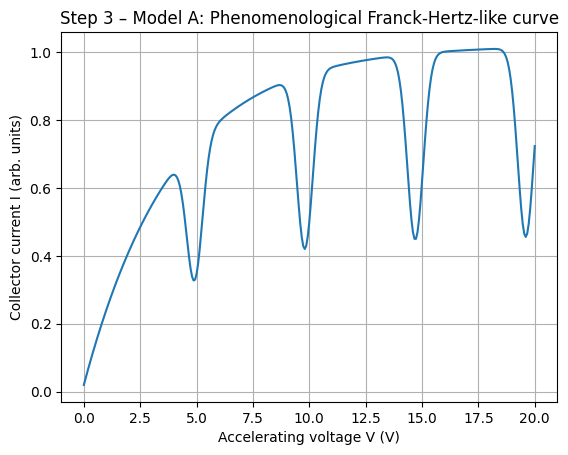

In [5]:
# Step 3 – Model A
def I_phenomenological(V, V0=4.9, depth=0.55, width=0.35, slope=1.0, offset=0.02, kmax=6):
    # Toy shape model: baseline rule with V, with dips near V = k*V0
    V = np.asarray(V)

    I_base = offset + slope * (1 - np.exp(-V/4.0))

    dips = np.zeros_like(V)
    for k in range(1, kmax + 1):
        dips += np.exp(-0.5 * ((V - k*V0) / width)**2)

    dips_norm = dips / (np.max(dips) + 1e-12)
    I = I_base * (1 - depth * dips_norm)

    return np.clip(I, 0, None)

I_A = I_phenomenological(V_array, V0=V0_guess)

plt.figure()
plt.plot(V_array, I_A)
plt.xlabel("Accelerating voltage V (V)")
plt.ylabel("Collector current I (arb. units)")
plt.title("Step 3 – Model A: Phenomenological Franck-Hertz-like curve")
plt.grid(True)
plt.show()

## Step 3: Explain why the pattern repeats near $V_0,2V_0,3V_0,...$ in this model

### 1 – Role of the retarding potential $V_r$: energy filtering after each excitation

### 2 – Quantized energy loss per inelastic collision: why the spacing is almlmost constant

### 3 – Experimenttal signature: extracting $V_0$ from peak-to-peak (or dip-to-dip) spacing

## Step 4 – Estimate $V_0$ from the curve (peak spacing)

In the Franck-Hertz curve, the spacing between succesive peaks (or succesive minima) is approximately $V_0$.
We will estimate $V_0$ from **peak-to-peak spacing**

Model A peak voltages (V): [ 4.     8.667 13.467 18.2  ]
Model A peak spacings (V): [4.667 4.8   4.733]
Model A estimated V0 (V): 4.733333333333333


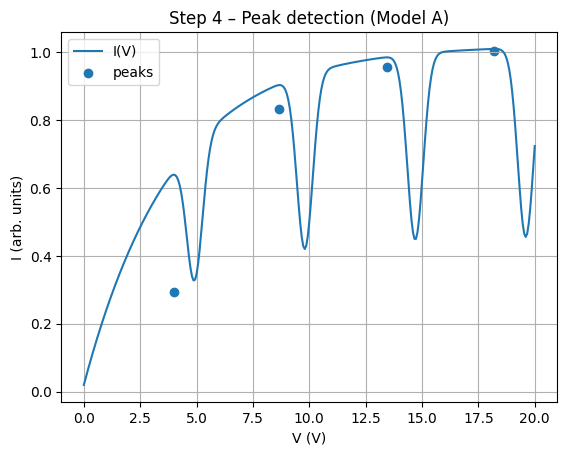

In [6]:
# Step 4 – Peak detection utilities
def estimate_V0_from_peaks(V, I, minV=2.0):
    V = np.asarray(V)
    I = np.asarray(I)

    if SCIPY_OK:
        peaks, props = find_peaks(I, prominence=0.02, distance=max(5, len(V)//50))
        V_peaks = V[peaks]
    else:
        peaks_idx = []
        for i in range(1, len(I)-1):
            if I[i] > I[i-1] and I[i] > I[i+1]:
                peaks_idx.append(i)
        peaks = np.array(peaks_idx, dtype = int)
        V_peaks = V[peaks]

    V_peaks = V_peaks[V_peaks > minV]
    spacings = np.diff(V_peaks)
    V0_est = np.mean(spacings) if len(spacings) > 0 else np.nan
    return V_peaks, spacings, V0_est

V_peaks_A, spacings_A, V0_est_A = estimate_V0_from_peaks(V_array, I_A)

print("Model A peak voltages (V):", np.round(V_peaks_A, 3))
print("Model A peak spacings (V):", np.round(spacings_A, 3))
print("Model A estimated V0 (V):", V0_est_A)

plt.figure()
plt.plot(V_array, I_A, label="I(V)")
plt.scatter(V_peaks_A, I_phenomenological(V_peaks_A, V0=V0_guess), label="peaks")
plt.xlabel("V (V)")
plt.ylabel("I (arb. units)")
plt.title("Step 4 – Peak detection (Model A)")
plt.grid(True)
plt.legend()
plt.show()

## Step 4: Compare your estimated $V_0$ to 4.9 V. Are they close? Why might they differ?

### 1 – Comparing your measured $V_0$ to the expected 4.9 V

### 2 – Why the $V_0$ estimate can differ: model parameters and peak detection 

### 3 – Interpretation: $V_0$ is a spacing, not a single point

## Step 5 – Model B (Monte Carlo collision simulation)

Now we simmulate the *mechanism*:

- Electrons accelerate across an effective distance $d$, gaining energy from the potential drop.

- Collisions occur randomly with mean free path $l$.

- If the electron energy is high enough, an **inelastic excitation** can occur and the electron loses $E_{exc}$

- The electron reaches the collector only if its final energy can overcome the retarding barrier $eV_r$.

**Importatn physical note**: elastic collisions with Hg barely change electron kinetic energy because Hg is much heavier than an electron.

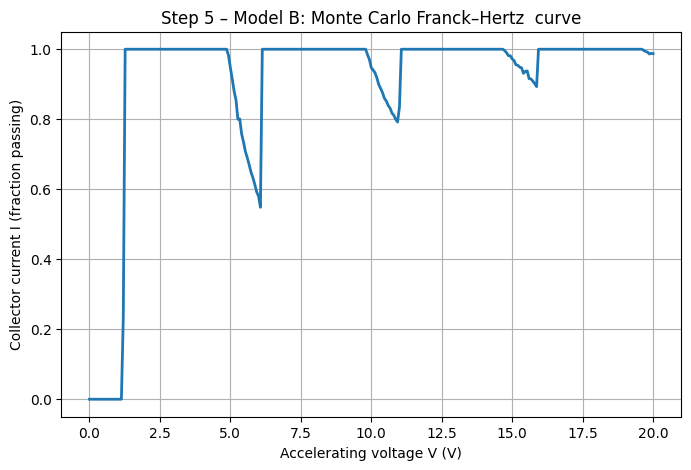

In [8]:
rng = np.random.default_rng(12345)

def simulate_current_MC(
    V, Vr=1.2, E_exc_eV=4.9,
    d=1.0e-2,             # effecctive acceleration distance (m)
    l_mfp=2.0e-3,         # mean free path (m) (pressure/temeperature proxy)
    p_inel=0.6,           # inelastic probability when allowed
    N=2500
):
    E_exc = E_exc_eV * e        # J
    barrier = e * Vr            # J
    
    passed = 0
    n_inel_list = []

    for _ in range(N):
        x = 0.0
        K = 0.0
        n_inel = 0
        
        while x < d:
            dx = rng.exponential(l_mfp)
            x_next = min(d, x + dx)
            
            # energy gain from linear potential drop between x and x_next
            K += e * V * (x_next - x) / d
            x = x_next
            
            if x >= d:
                break

            # inelastic collision if allowed
            if (K >= E_exc) and (rng.random() < p_inel):
                K -= E_exc
                n_inel += 1
        
        # retarding filter    
        if K > barrier:
            passed += 1
        
        n_inel_list.append(n_inel)
            
    I_norm = passed / N
    stats = {"mean_inelastic": float(np.mean(n_inel_list))}
    return I_norm, stats

# Run the scan
E_exc_eV = 4.9
Vr = Vr_default

I_B = np.zeros_like(V_array)
mean_inel = np.zeros_like(V_array)

for i, V in enumerate(V_array):
    I_norm, stats = simulate_current_MC(V, Vr=Vr, E_exc_eV=E_exc_eV, N=2500)
    I_B[i] = I_norm
    mean_inel[i] = stats["mean_inelastic"]

plt.figure(figsize=(8,5))
plt.plot(V_array, I_B, lw=2)
plt.xlabel("Accelerating voltage V (V)")
plt.ylabel("Collector current I (fraction passing)")
plt.title("Step 5 – Model B: Monte Carlo Franck–Hertz  curve")
plt.grid(True)
plt.show()


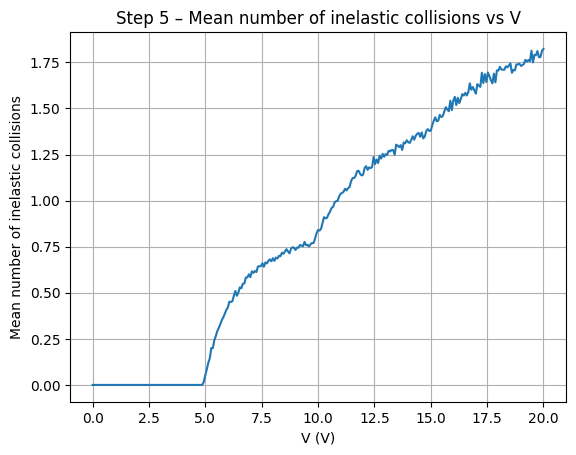

In [9]:
plt.figure()
plt.plot(V_array, mean_inel)
plt.xlabel("V (V)")
plt.ylabel("Mean number of inelastic collisions")
plt.title("Step 5 – Mean number of inelastic collisions vs V")
plt.grid(True)
plt.show()

## Step 5: Explain in 1-3 sentences why the mean number of inelastic collisions increases with $V$.

### 1 – More energy + more opportunities to excite the atom

### 2 – Crossing the threshold earlier along the path increases the count

### 3 – Multiple of $V_0$: repeated excitations become energetically possible

## Step 6 – Compare Model A and Model B 

Overlay normalized currents to compare shapes


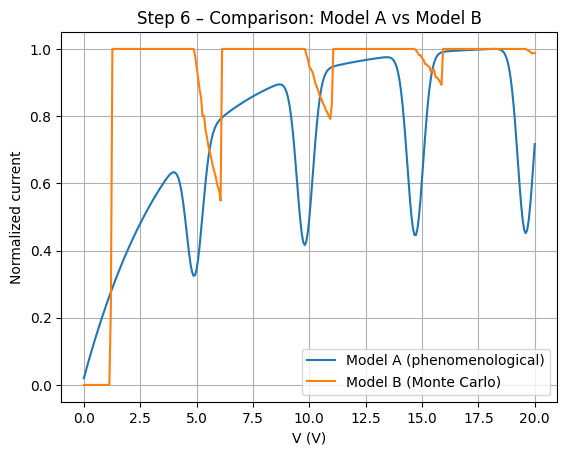

In [10]:
I_A_n = I_A / (np.max(I_A) + 1e-12)
I_B_n = I_B / (np.max(I_B) + 1e-12)

plt.figure()
plt.plot(V_array, I_A_n, label="Model A (phenomenological)")
plt.plot(V_array, I_B_n, label="Model B (Monte Carlo)")
plt.xlabel("V (V)")
plt.ylabel("Normalized current")
plt.title("Step 6 – Comparison: Model A vs Model B")
plt.grid(True)
plt.legend()
plt.show()

## Step 6: Which model better explains why the pattern occurs? Which model better matches a smooth-looking experimental curve?

### 1 – Mechanism vs appearance: Model B explains "why", Model A mimics the shape

### 2 – Model A is a clean reference; Model B is the physics

### 3 – Why the curves differ: noise and randomness


## Step 7 – Higher excited state feature

In many Franck-Hertz curves, a higher resolution plot can show additional features (e.g., near **6.7 V** for Hg). To model this, we allow **two excitation energies**:

- $E_1 \approx 4.9$ eV (first escited state)

- $E_2 \approx6.7$ eV (a higher excited state)

At each collision, if the electron has enough energy, it may lose  $E_2$ (less likely) or $E_1$ (more likely).

**TODO**: Run the model and compare the curve to the one-level Model B.


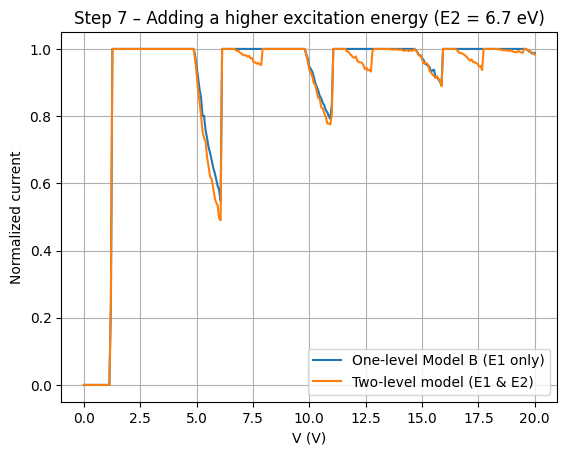

In [11]:
# Step 7 – Two-excitation Monte Carlo model (mandatory)

def simulate_current_MC_two_levels(
    V, Vr=1.2, E_exc_eV=4.9,
    E1_eV=4.9, p1=0.55,
    E2_eV=6.7, p2=0.18,
    d=1.0e-2, l_mfp=2.0e-3, N=2500
):
    E1 = E1_eV * e
    E2 = E2_eV * e
    barrier = e * Vr
    
    passed = 0
    
    # Lista para recolectar estadísticas si las necesitas
    n_inel_list = []

    for _ in range(N):
        x = 0.0
        K = 0.0
        while x < d:
            dx = rng.exponential(l_mfp)
            x_next = min(d, x + dx)
            K += e * V * (x_next - x) / d
            x = x_next
            if x >= d:
                break

            r = rng.random()
            # Verificación de colisión inelástica
            if (K >= E2) and (r < p2):
                K -= E2
            elif (K >= E1) and (r < (p2+p1)):
                K -= E1
        
        if K > barrier:
            passed += 1
        
    return passed / N

I_two = np.zeros_like(V_array)

# Ejecutar el escaneo
for i, V in enumerate(V_array):
    I_two[i] = simulate_current_MC_two_levels(V, Vr=Vr_default, N=2500)
    
I_two_n = I_two / (np.max(I_two) + 1e-12)

# Visualización
plt.figure()
plt.plot(V_array, I_B_n, label="One-level Model B (E1 only)")
plt.plot(V_array, I_two_n, label="Two-level model (E1 & E2)")
plt.xlabel("V (V)")
plt.ylabel("Normalized current")
plt.title("Step 7 – Adding a higher excitation energy (E2 = 6.7 eV)")
plt.grid(True)
plt.legend()
plt.show()

## Step 7: Does adding $E_2$ introduce new structure? Where (approximately) does it appear and why?

### 1 – New threshold $\rightarrow$ new feature near the second excitation energy

### 2 – Extra dip/shoulder due to a second inelastic loss channel

### 3 – Why it may be subtle: competition between two excitation processes


## Step 8 – Virtual experiment: sweep the retarding potential $V_r$

In the real apparatus, $V_r$ is an energy filter. Larger $V_r$ rejects more electrons and changes the observed current curve.


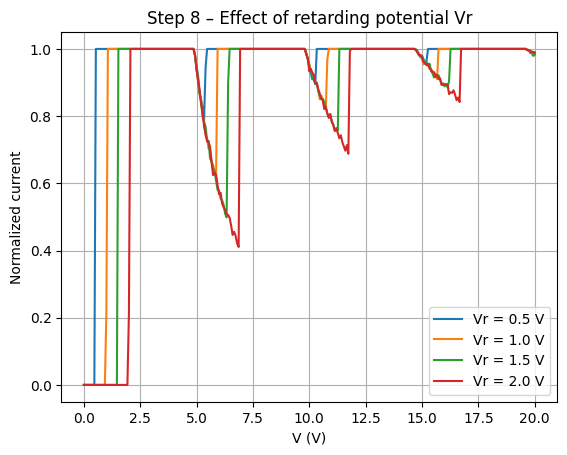

In [12]:
# Step 8 – Sweep Vr (mandatory)
Vr_list = [0.5, 1.0, 1.5, 2.0]   # V

plt.figure()
for Vr_test in Vr_list:
  I_curve = np.zeros_like(V_array)
  for i, V in enumerate(V_array):
    I_norm, _ = simulate_current_MC(V, Vr=Vr_test, E_exc_eV=E_exc_eV, N=2000)
    I_curve[i] = I_norm
  I_curve_n = I_norm
  I_curve_n = I_curve / (np.max(I_curve) + 1e-12)
  plt.plot(V_array, I_curve_n, label=f"Vr = {Vr_test:.1f} V")

plt.xlabel("V (V)")
plt.ylabel("Normalized current")
plt.title("Step 8 – Effect of retarding potential Vr")
plt.grid(True)
plt.legend()
plt.show()


## Step 8: Explain how and why increasing $V_r$ changes the curve.

### 1 – $V_r$ is an energy filter: higher $V_r$ blocks more electrons

### 2 – Stronger retarding field increases sensitivity to energy loss

### 3 – What $V_r$ does NOT change: it does not move the energy levels


## Step 9 – "Measurement": add noise and estimate $V_0$ (mandatory)

We treat the Monte Carlo curve as "measured data" and add small random noise, then estimate $V_0$ from peak spacing.


Estimated V0 from noisy 'measurement' (V): 0.6820512820512821
Estimated excitation energy E_exc (eV): 0.6820512820512821


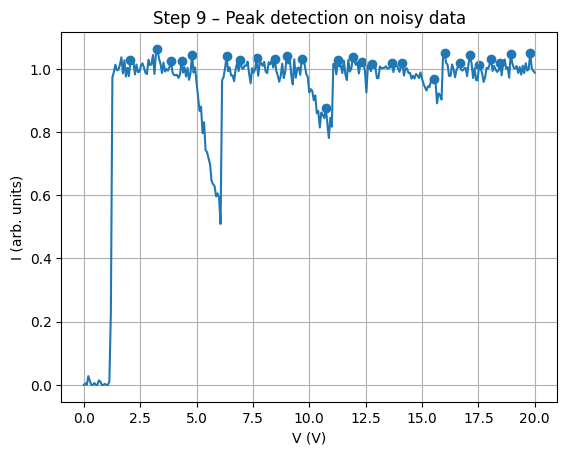

In [13]:
# Step 9 – Add synthetic noise and estimate V0
rng_noise = np.random.default_rng(2026)
noise_level = 0.02

I_meas = np.clip(I_B + noise_level * rng_noise.normal(size=I_B.shape), 0, 
None)

V_peaks_meas, spacing_meas, V0_est_meas = estimate_V0_from_peaks(V_array, 
I_meas)
print("Estimated V0 from noisy 'measurement' (V):", V0_est_meas)

plt.figure()
plt.plot(V_array, I_meas, label="Noisy measurement")
plt.scatter(V_peaks_meas, I_meas[np.searchsorted(V_array, V_peaks_meas)], 
label="Detected peaks")
plt.xlabel("V (V)")
plt.ylabel("I (arb. units)")
plt.title("Step 9 – Peak detection on noisy data")
plt.grid(True)
plt.show

# Excitating energy estimate: E_exc (eV) = V0 (V)
E_exc_est_eV = V0_est_meas
print("Estimated excitation energy E_exc (eV):", E_exc_est_eV)


### 1 – Close agreement with the expected mercury value

### 2 – Noise and resolution explain small differences

### 3 – Why "not exactly 4.9" does not mean "wrong"


## Step 10 – Spectroscopic check: compute $\lambda, \nu$ and $\bar{\nu}$

If the atom absorbs energy $E_{exc}$, it can emit a photon of similar energy when de-exciting:

$$\lambda \approx \frac{hc}{E_{\gamma}} \approx \frac{hc}{E_{exc}}$$

Compute:

- wavelength $\lambda$ in **nm**.

- frequency $\nu = c/\lambda$ in **Hz**.

- wavenumber $\bar{\nu}=1/\lambda$ in **cm**$^{-1}$.

Compare to the mercury UV line near **253.6 nm**


In [14]:
# Step 10 – Spectroscopic calculations
def energy_eV_to_lambda_nm(E_eV):
  E_J = E_eV * e
  lam_m = h * c / E_J
  return lam_m * 1e9

lam_nm = energy_eV_to_lambda_nm(E_exc_est_eV)
lam_m = lam_nm * 1e-9

# Frequency (Hz)
nu = c / lam_m

# Wavenumber (cm^-1): 1/lambda with lambda in cm
lam_cm = lam_nm * 1e-7 # 1 nm = 1e-7 cm
nu_tilde = 1.0 / lam_cm

print(f"Predicted wavelength lambda = {lam_nm:.2f} nm")
print(f"Frequency v = {nu:.3e} Hz")
print(f"Wavenumber v~ = {nu_tilde:.0f} cm^-1")


Predicted wavelength lambda = 1817.81 nm
Frequency v = 1.649e+14 Hz
Wavenumber v~ = 5501 cm^-1


## Step 10: Explain why the predicted wavelength is in the ultraviolet and why it appears inly after the threshold voltage.

### 2 – The UV line appears only after electrons can excite Hg

### 3 – Threshold behavior is evidence of quantized energy levels


Percent error vs 253.6 nm: +616.80%


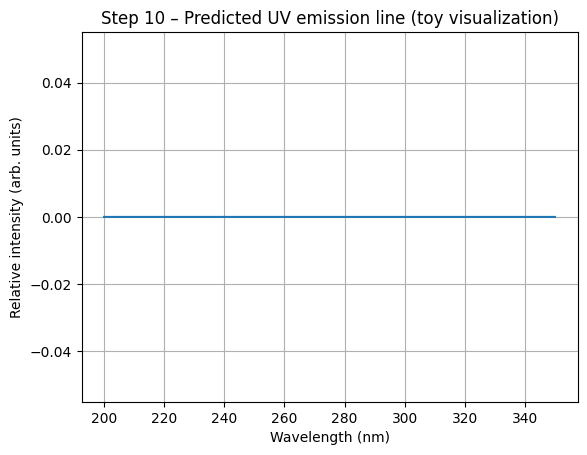

In [15]:
# Compare to expected Hg UV line ~253.6 nm
lam_expected = 253.6
percent_error = 100.0 * (lam_nm - lam_expected) / lam_expected
print(f"Percent error vs 253.6 nm: {percent_error:+.2f}%")

# Plot a toy "spectral line" centered at the predicted wavelength
lam_axis = np.linspace(200, 350, 2000)  # nm
sigma = 2.0                             # nm (visual width only)
line = np.exp(-0.5 * ((lam_axis - lam_nm) / sigma)**2)

plt.figure()
plt.plot(lam_axis, line)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative intensity (arb. units)")
plt.title("Step 10 – Predicted UV emission line (toy visualization)")
plt.grid(True)
plt.show()


**TODO (write below)**: Explain why the predicted wavelength is in the ultraviolet and why it appears only after the threshold voltage


## Step 11 – Concept check: why not every feature matches an optical line?

In Franck-Hertz, current features are produced by **collisions** (impact excitations). Spectral lines are produced by **radiative transitions**. Not all transitions are radiatively allowed:

- **Optical selection rules** may forbid some radiative lines.

- **Collision (impact) selection rules** can differ from optical ones.

Therefore, not every voltage feature must correspond to a strong optical line.

**TODO (write below)**: In 3-5 sentences, explain the difference between *impact excitation* and *radiative emission*, and why selection rules matter.


## Step 11: In 3–5 sentences, explain the difference between impact excitation and radiative emission, and why selection rules matter.

### 1 – Collisions create excitations; light is emitted later when atoms relax

### 2 – Different "rule" for collisional vs optical transitions

### 3 – Why the spectrum is not a perfect "mirror" of the current curve


## Step 12 – Results summary (mandatory)

Create a short summary with your final values:

- Estimated $V_0 (V)$

- Estimated $E_{exc} (eV)$

- Predicted $\lambda (nm)$

- Predicted $\tilde{\nu}$ cm$^{-1}$

- Percent error vs  253.6 nm

**TODO**: Fill in the summary below with your computed values.


In [16]:
## Step 12 – Auto-fill the summary values (you still write the interpretation 
## in Markdown)

summary = {
  'V0_est (V)': float(V0_est_meas),
  'E_exc_est (eV)': float(E_exc_est_eV),
  'lambda_pred (nm)': float(lam_nm),
  'nu_tilde (cm^-1)': float(nu_tilde),
  'percent_error_vs 253.6_nm (%)': float(percent_error)
}
summary


{'V0_est (V)': 0.6820512820512821,
 'E_exc_est (eV)': 0.6820512820512821,
 'lambda_pred (nm)': 1817.813435674741,
 'nu_tilde (cm^-1)': 5501.114582909975,
 'percent_error_vs 253.6_nm (%)': 616.8034052345193}

## Step 12: Fill in the summary below with your computed values.

### 1 – Results summary

- Estimated $V_0: 0.6820512820512821$ $V$

- Estimated $E_{exc}: 0.6820512820512821$ $eV$

- Predicted wavelength $\lambda = hc/E_{exc}:817.813435674741$ nm

- Predicted wavenumber $\tilde{\nu} = 1/\lambda:5501.114582909975$ cm$^{-1}$

- Percent error vs 253.6 nm: $6.8034052345193$ %

Conclusion (2-3 lines):

### 2 – Results summary (with a short interpretation)

Measured from the $I(V)$ pattern: $V_0: 0.6820512820512821$ $V\rightarrow E_{exc} = 817.813435674741$ $eV$

Spectroscopy check:

- $\lambda = 817.813435674741$ nm

- $\tilde{\nu} = 5501.114582909975$ cm$^{-1}$

- Error (vs 253.6 nm) = $6.8034052345193$ %

**Interpretation (2-3 lines):**

### 3 – Results Summary (very concise)

$V_0 = 0.6820512820512821$ $V$, $E_{exc} = 817.813435674741$ $eV$, $\lambda = 817.813435674741$ nm, $\tilde{\nu} = 5501.114582909975$ cm$^{-1}$, error = $6.8034052345193$ %

**Final conclusion (2-3 lines):**